In [2]:
!pip install opencv-python matplotlib

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files


Saving friendship-cat-dog-sheep.webp to friendship-cat-dog-sheep.webp


(np.float64(-0.5), np.float64(799.5), np.float64(532.5), np.float64(-0.5))

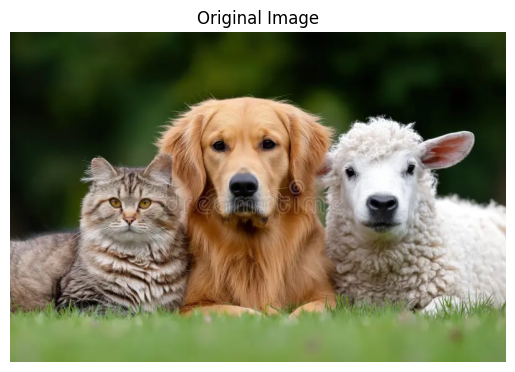

In [8]:
uploaded = files.upload()
img_path = list(uploaded.keys())[0]

img = cv2.imread(img_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img_rgb)
plt.title("Original Image")
plt.axis("off")


(np.float64(-0.5), np.float64(799.5), np.float64(532.5), np.float64(-0.5))

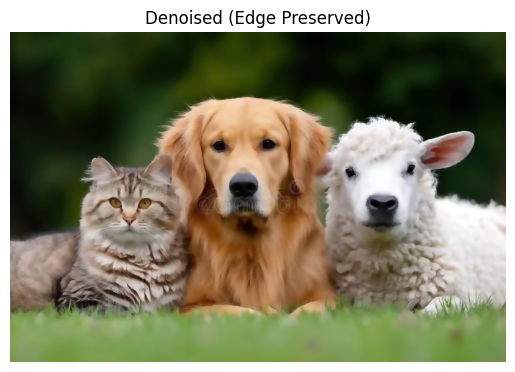

In [9]:
denoised = cv2.bilateralFilter(
    img,
    d=9,
    sigmaColor=75,
    sigmaSpace=75
)

denoised_rgb = cv2.cvtColor(denoised, cv2.COLOR_BGR2RGB)

plt.imshow(denoised_rgb)
plt.title("Denoised (Edge Preserved)")
plt.axis("off")


(np.float64(-0.5), np.float64(799.5), np.float64(532.5), np.float64(-0.5))

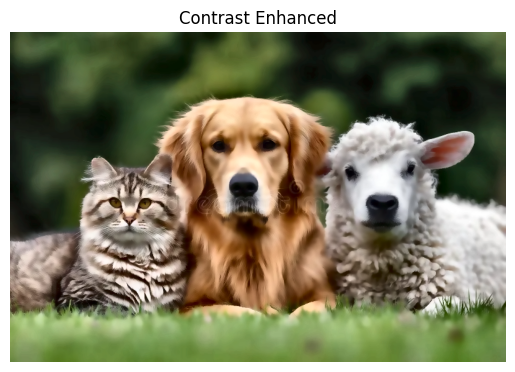

In [10]:
lab = cv2.cvtColor(denoised, cv2.COLOR_BGR2LAB)
l, a, b = cv2.split(lab)

clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
l2 = clahe.apply(l)

lab = cv2.merge((l2,a,b))
contrast = cv2.cvtColor(lab, cv2.COLOR_LAB2BGR)

contrast_rgb = cv2.cvtColor(contrast, cv2.COLOR_BGR2RGB)

plt.imshow(contrast_rgb)
plt.title("Contrast Enhanced")
plt.axis("off")


(np.float64(-0.5), np.float64(799.5), np.float64(532.5), np.float64(-0.5))

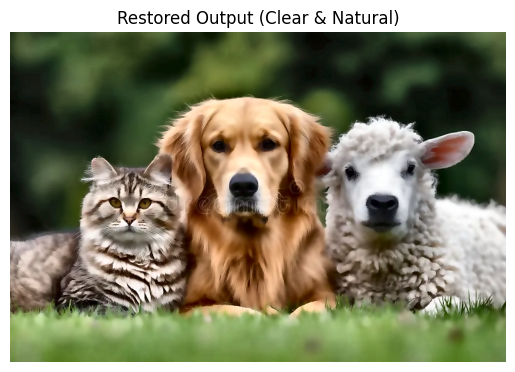

In [11]:
gaussian = cv2.GaussianBlur(contrast, (0,0), sigmaX=1.0)
sharpened = cv2.addWeighted(
    contrast, 1.5,
    gaussian, -0.5,
    0
)

sharpened_rgb = cv2.cvtColor(sharpened, cv2.COLOR_BGR2RGB)

plt.imshow(sharpened_rgb)
plt.title("Restored Output (Clear & Natural)")
plt.axis("off")


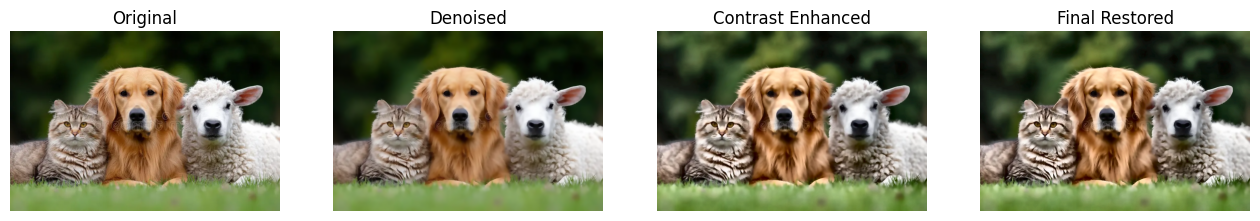

In [12]:
plt.figure(figsize=(16,4))

plt.subplot(1,4,1)
plt.imshow(img_rgb)
plt.title("Original")
plt.axis("off")

plt.subplot(1,4,2)
plt.imshow(denoised_rgb)
plt.title("Denoised")
plt.axis("off")

plt.subplot(1,4,3)
plt.imshow(contrast_rgb)
plt.title("Contrast Enhanced")
plt.axis("off")

plt.subplot(1,4,4)
plt.imshow(sharpened_rgb)
plt.title("Final Restored")
plt.axis("off")

plt.show()
